Task 1 - Data Analysis and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (48895, 16)

Columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [3]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values("Missing Values", ascending=False)

,Missing Values,Missing Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


In [4]:
print("Listings with no reviews:")
print((df["number_of_reviews"] == 0).sum())

print("\nMissing reviews_per_month among listings with no reviews:")
print(
    ((df["number_of_reviews"] == 0) &
     (df["reviews_per_month"].isna())).sum()
)

print("\nMissing last_review among listings with no reviews:")
print(
    ((df["number_of_reviews"] == 0) &
     (df["last_review"].isna())).sum()
)

Listings with no reviews:
10052

Missing reviews_per_month among listings with no reviews:
10052

Missing last_review among listings with no reviews:
10052


In [5]:
# Handle missing values

df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["host_name"] = df["host_name"].fillna("Unknown")
df["name"] = df["name"].fillna("Unknown")

# last_review will be handled during feature engineering
# because we may extract useful information from the review date.

print("Remaining missing values:")
print(df.isnull().sum().sort_values(ascending=False))

Remaining missing values:
last_review                       10052
id                                    0
host_id                               0
name                                  0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
host_name                             0
longitude                             0
room_type                             0
minimum_nights                        0
price                                 0
number_of_reviews                     0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [6]:
# Drop last_review because it has substantial missingness
# and is not required as an input for the price prediction application.

df = df.drop(columns=["last_review"])

print("Shape after dropping last_review:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Shape after dropping last_review: (48895, 15)

Remaining missing values:
0


In [7]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# Statistical summary of the target variable
df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [9]:
# Check minimum and maximum prices
print("Minimum price:", df["price"].min())
print("Maximum price:", df["price"].max())

# Check listings with zero price
print("Listings with price = 0:", (df["price"] == 0).sum())

Minimum price: 0
Maximum price: 10000
Listings with price = 0: 11


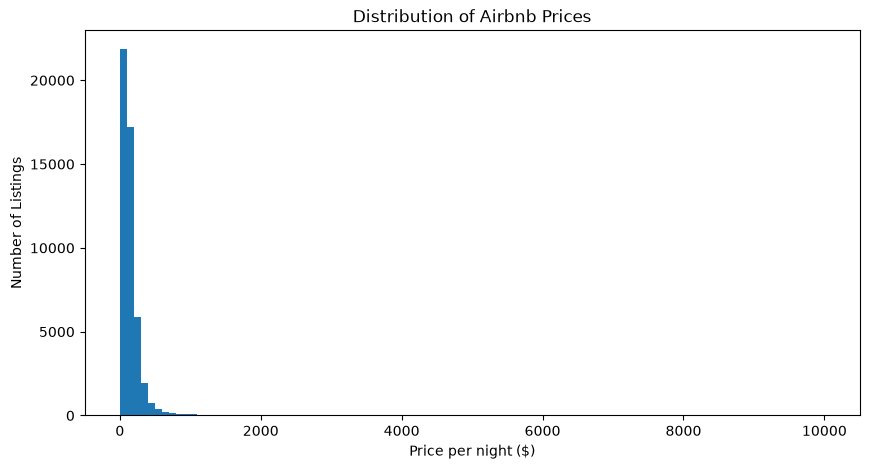

In [10]:
# Distribution of Airbnb prices
plt.figure(figsize=(10, 5))
plt.hist(df["price"], bins=100)
plt.xlabel("Price per night ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

In [11]:
df[df["price"] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,0.00,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,0.11,6,333


In [12]:
# Remove listings with zero price
zero_price_count = (df["price"] == 0).sum()

df = df[df["price"] > 0].copy()

print("Zero-price listings removed:", zero_price_count)
print("New dataset shape:", df.shape)

Zero-price listings removed: 11
New dataset shape: (48884, 15)


In [13]:
# Calculate IQR for price
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

print("Number of price outliers:", len(outliers))
print("Percentage of price outliers:", 
      len(outliers) / len(df) * 100)

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower Bound: -90.0
Upper Bound: 334.0
Number of price outliers: 2972
Percentage of price outliers: 6.079698878978808


In [14]:
# Examine the upper tail of the price distribution
percentiles = df["price"].quantile([
    0.90,
    0.95,
    0.97,
    0.98,
    0.99,
    0.995,
    1.00
])

print(percentiles)

0.900      269.0
0.950      355.0
0.970      450.0
0.980      550.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64


In [15]:
# Count listings above different price thresholds
thresholds = [334, 500, 750, 1000, 1500, 2000, 5000]

for threshold in thresholds:
    count = (df["price"] > threshold).sum()
    percentage = count / len(df) * 100
    print(f"Price > ${threshold}: {count} listings ({percentage:.2f}%)")

Price > $334: 2972 listings (6.08%)
Price > $500: 1044 listings (2.14%)
Price > $750: 508 listings (1.04%)
Price > $1000: 239 listings (0.49%)
Price > $1500: 139 listings (0.28%)
Price > $2000: 86 listings (0.18%)
Price > $5000: 20 listings (0.04%)


C:\Users\Hirav\AppData\Local\Temp\ipykernel_26832\2319611364.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["price"], vert=False)


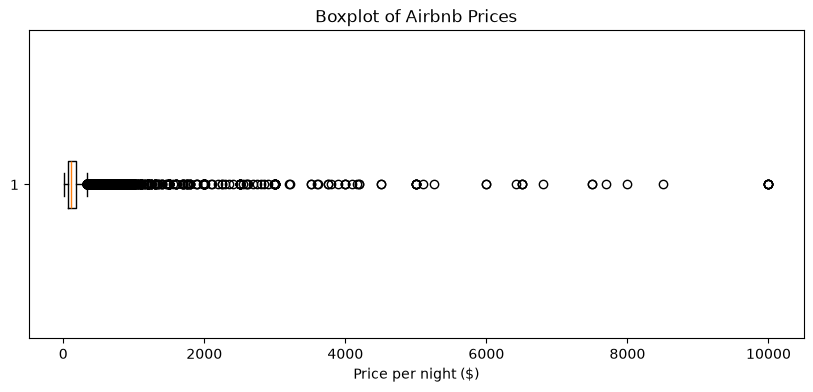

In [16]:
# Boxplot of Airbnb prices
plt.figure(figsize=(10, 4))
plt.boxplot(df["price"], vert=False)
plt.xlabel("Price per night ($)")
plt.title("Boxplot of Airbnb Prices")
plt.show()

In [17]:
# Inspect extremely high-priced listings
df[df["price"] > 5000][
    ["name", "neighbourhood_group", "neighbourhood", "room_type", "price"]
].sort_values("price", ascending=False)

,name,neighbourhood_group,neighbourhood,room_type,price
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000
29238,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000
9151,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000
6530,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500
4377,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703
42523,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,7500


In [18]:
# Distribution of room types
print("Room Type Distribution:")
print(df["room_type"].value_counts())

print("\nNeighbourhood Group Distribution:")
print(df["neighbourhood_group"].value_counts())

Room Type Distribution:
room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64

Neighbourhood Group Distribution:
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64


In [19]:
# Average price by room type
room_price = df.groupby("room_type")["price"].agg(["count", "mean", "median"])
room_price.sort_values("mean", ascending=False)

,count,mean,median
room_type,,,
Entire home/apt,25407,211.810918,160.0
Private room,22319,89.809131,70.0
Shared room,1158,70.248705,45.0


In [20]:
# Average price by neighbourhood group
neighbourhood_price = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

neighbourhood_price

,count,mean,median
neighbourhood_group,,,
Manhattan,21660,196.884903,150.0
Brooklyn,20095,124.438915,90.0
Staten Island,373,114.812332,75.0
Queens,5666,99.517649,75.0
Bronx,1090,87.577064,65.0


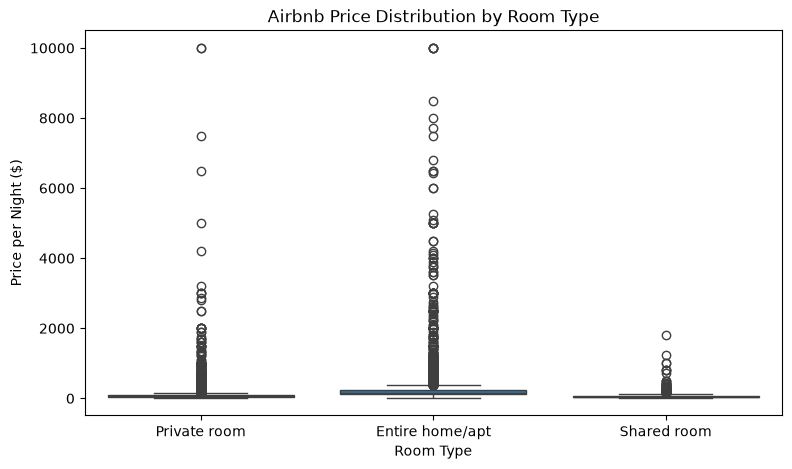

In [21]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.xlabel("Room Type")
plt.ylabel("Price per Night ($)")
plt.title("Airbnb Price Distribution by Room Type")
plt.show()

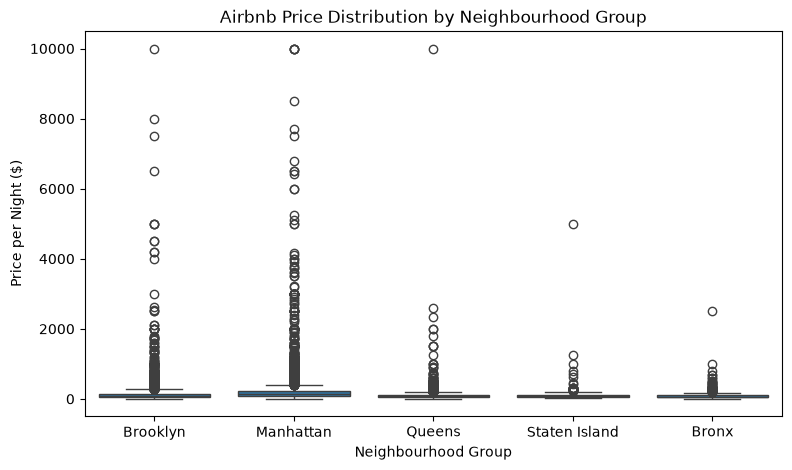

In [22]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price"
)

plt.xlabel("Neighbourhood Group")
plt.ylabel("Price per Night ($)")
plt.title("Airbnb Price Distribution by Neighbourhood Group")
plt.show()

In [23]:
# Summary statistics for numerical features
numeric_cols = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "price"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
minimum_nights,48884.0,7.029887,20.512224,1.0,1.00,3.00,5.00,1250.0
number_of_reviews,48884.0,23.271991,44.551331,0.0,1.00,5.00,24.00,629.0
reviews_per_month,48884.0,1.090800,1.597213,0.0,0.04,0.37,1.58,58.5
calculated_host_listings_count,48884.0,7.144628,32.956185,1.0,1.00,1.00,2.00,327.0
availability_365,48884.0,112.779498,131.627271,0.0,0.00,45.00,227.00,365.0
price,48884.0,152.755053,240.170260,10.0,69.00,106.00,175.00,10000.0


In [24]:
# Correlation of numerical features with price
correlation = df[numeric_cols].corr()["price"].sort_values(ascending=False)

correlation

price                             1.000000
availability_365                  0.081847
calculated_host_listings_count    0.057462
minimum_nights                    0.042805
number_of_reviews                -0.047926
reviews_per_month                -0.050531
Name: price, dtype: float64

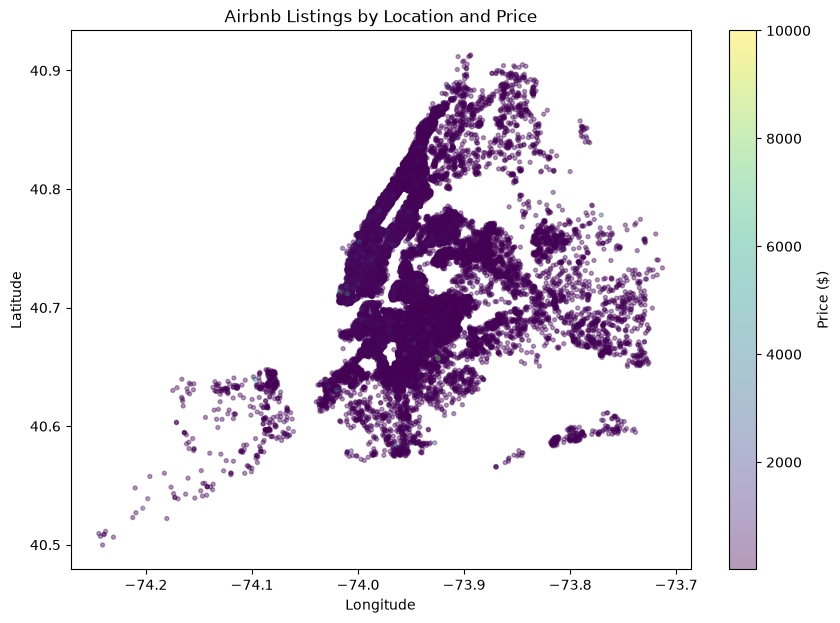

In [25]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price"],
    s=8,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Airbnb Listings by Location and Price")
plt.colorbar(label="Price ($)")
plt.show()

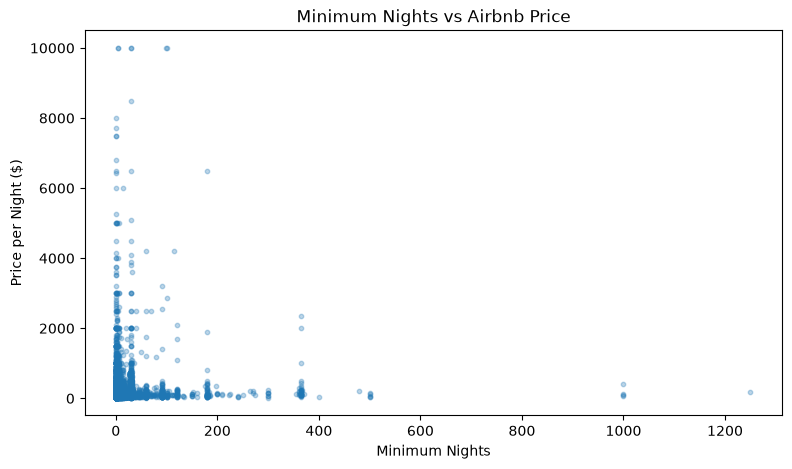

In [26]:
# Minimum nights vs price
plt.figure(figsize=(9, 5))

plt.scatter(
    df["minimum_nights"],
    df["price"],
    alpha=0.3,
    s=10
)

plt.xlabel("Minimum Nights")
plt.ylabel("Price per Night ($)")
plt.title("Minimum Nights vs Airbnb Price")
plt.show()

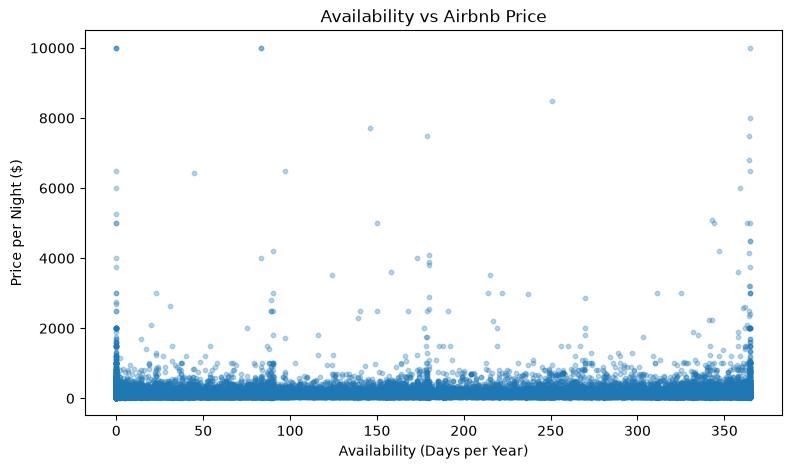

In [27]:
# Availability vs price
plt.figure(figsize=(9, 5))

plt.scatter(
    df["availability_365"],
    df["price"],
    alpha=0.3,
    s=10
)

plt.xlabel("Availability (Days per Year)")
plt.ylabel("Price per Night ($)")
plt.title("Availability vs Airbnb Price")
plt.show()

In [28]:
# Feature engineering for skewed numerical variables

df["log_minimum_nights"] = np.log1p(df["minimum_nights"])
df["log_number_of_reviews"] = np.log1p(df["number_of_reviews"])
df["log_reviews_per_month"] = np.log1p(df["reviews_per_month"])
df["log_host_listings_count"] = np.log1p(df["calculated_host_listings_count"])
df["log_availability_365"] = np.log1p(df["availability_365"])

df[[
    "minimum_nights",
    "log_minimum_nights",
    "number_of_reviews",
    "log_number_of_reviews",
    "availability_365",
    "log_availability_365"
]].head()

,minimum_nights,log_minimum_nights,number_of_reviews,log_number_of_reviews,availability_365,log_availability_365
0,1,0.693147,9,2.302585,365,5.902633
1,1,0.693147,45,3.828641,355,5.874931
2,3,1.386294,0,0.000000,365,5.902633
3,1,0.693147,270,5.602119,194,5.273000
4,10,2.397895,9,2.302585,0,0.000000


In [29]:
# Define features for price prediction

features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_host_listings_count",
    "log_availability_365"
]

target = "price"

X = df[features]
y = df[target]

print("Number of features:", len(features))
print("\nFeatures:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of features: 10

Features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'log_minimum_nights', 'log_number_of_reviews', 'log_reviews_per_month', 'log_host_listings_count', 'log_availability_365']

X shape: (48884, 10)
y shape: (48884,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (39107, 10)
Testing set: (9777, 10)


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_host_listings_count",
    "log_availability_365"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


TASK 2 — Model Training & Evaluation

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [34]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Gradient Boosting,66.072454,181.446232,0.177671
0,Linear Regression,70.967916,185.018862,0.144969
1,Random Forest,66.867797,196.738592,0.033217


In [35]:
# Log-transform the target to reduce the influence of extreme prices
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original target range:")
print(y_train.min(), "to", y_train.max())

print("\nLog-transformed target range:")
print(y_train_log.min(), "to", y_train_log.max())

Original target range:
10 to 10000

Log-transformed target range:
2.3978952727983707 to 9.210440366976517


In [36]:
log_models = {
    "Linear Regression (Log Target)": LinearRegression(),
    "Random Forest (Log Target)": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting (Log Target)": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [37]:
log_results = []

for name, model in log_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_log)

    # Predict in log scale
    y_pred_log = pipeline.predict(X_test)

    # Convert predictions back to original price scale
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    log_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

log_results_df = pd.DataFrame(log_results)

log_results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,Random Forest (Log Target),56.318674,175.135248,0.233880
2,Gradient Boosting (Log Target),57.489017,184.295478,0.151642
0,Linear Regression (Log Target),59.203844,185.838941,0.137372


In [38]:
# Build the baseline Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_pipeline.fit(X_train, y_train_log)

# Training predictions
train_pred_log = rf_pipeline.predict(X_train)
train_pred = np.expm1(train_pred_log)

# Testing predictions
test_pred_log = rf_pipeline.predict(X_test)
test_pred = np.expm1(test_pred_log)

# Calculate metrics
train_mae = mean_absolute_error(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

print("Training Performance")
print("--------------------")
print("MAE :", train_mae)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nTesting Performance")
print("-------------------")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

Training Performance
--------------------
MAE : 25.57492766513524
RMSE: 157.13219491935686
R²  : 0.6023489879392827

Testing Performance
-------------------
MAE : 56.31867404612385
RMSE: 175.1352484172469
R²  : 0.23387965363889685


In [39]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_pipeline_tuning = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.7]
}

In [40]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline_tuning,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train_log)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE (log scale):")
print(-random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20}

Best CV RMSE (log scale):
0.4339182834021938


In [41]:
# Evaluate the tuned Random Forest on the test set

best_rf = random_search.best_estimator_

# Predictions in log scale
tuned_pred_log = best_rf.predict(X_test)

# Convert predictions back to original price scale
tuned_pred = np.expm1(tuned_pred_log)

# Calculate test metrics
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned Random Forest - Test Performance")
print("---------------------------------------")
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²  :", tuned_r2)

Tuned Random Forest - Test Performance
---------------------------------------
MAE : 55.31566447458711
RMSE: 176.97365591798342
R²  : 0.21771119343324974


In [42]:
# Check overfitting of the tuned Random Forest

tuned_train_pred_log = best_rf.predict(X_train)
tuned_train_pred = np.expm1(tuned_train_pred_log)

tuned_train_mae = mean_absolute_error(y_train, tuned_train_pred)
tuned_train_rmse = np.sqrt(mean_squared_error(y_train, tuned_train_pred))
tuned_train_r2 = r2_score(y_train, tuned_train_pred)

print("Tuned Random Forest - Training Performance")
print("-------------------------------------------")
print("MAE :", tuned_train_mae)
print("RMSE:", tuned_train_rmse)
print("R²  :", tuned_train_r2)

print("\nTuned Random Forest - Testing Performance")
print("-----------------------------------------")
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²  :", tuned_r2)

Tuned Random Forest - Training Performance
-------------------------------------------
MAE : 37.27073663145001
RMSE: 199.66724847577234
R²  : 0.35792552645906806

Tuned Random Forest - Testing Performance
-----------------------------------------
MAE : 55.31566447458711
RMSE: 176.97365591798342
R²  : 0.21771119343324974


In [43]:
import joblib

# Final model: Random Forest with log-transformed target
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train final model on the training data
final_model.fit(X_train, y_train_log)

# Save the complete pipeline
joblib.dump(final_model, "airbnb_price_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [44]:
# Load the saved model
loaded_model = joblib.load("airbnb_price_model.pkl")

# Make a sample prediction using the first test observation
sample_prediction_log = loaded_model.predict(X_test.iloc[[0]])

# Convert back to original price scale
sample_prediction = np.expm1(sample_prediction_log)[0]

print("Predicted price:", round(sample_prediction, 2))
print("Actual price:", y_test.iloc[0])

Predicted price: 94.39
Actual price: 99
